In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gensim
!pip install contractions
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00


In [ ]:
# BASIC LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import time

#  NLP - NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

nltk.download('stopwords')
nltk.download('wordnet')

# CONTRACTIONS HANDLING
import contractions

# VISUALIZATION
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns

# DATA SPLITTING & ENCODING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

#  KERAS PREPROCESSING
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# DEEP LEARNING MODELS
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EVALUATION METRICS
from sklearn.metrics import classification_report, confusion_matrix

# WORD2VEC (PRETRAINED / GENSIM)
import gensim.downloader as api

# GUI
import gradio as gr

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


# Text Preprocessing, Tokenization, and Sequence Padding:

### Load the dataset:

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/AI and ML/COURSEWORK/Text Classification/financial_phrase.csv")
data.head()

,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [ ]:
print("Shape:", data.shape)
print("\nColumns:", data.columns)
print("\nInfo:")
data.info()

Shape: (2264, 2)

Columns: Index(['text', 'label'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2264 non-null   object
 1   label   2264 non-null   object
dtypes: object(2)
memory usage: 35.5+ KB


Label distribution:

label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


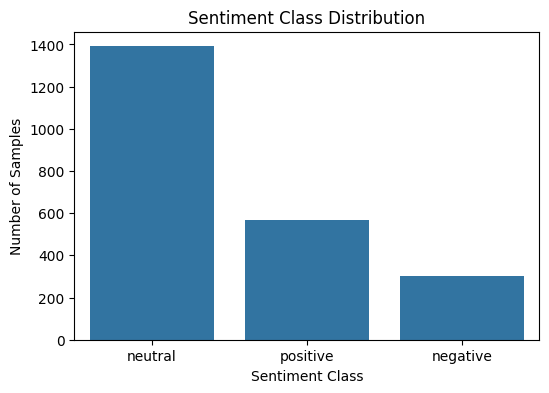

In [ ]:
# Label Distribution

# Check class distribution
print("Label distribution:\n")
print(data['label'].value_counts())

plt.figure(figsize=(6,4))

# Countplot shows frequency of each class
sns.countplot(x='label', data=data)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Samples")

plt.show()

### Clean the text:

In [ ]:
# Setup
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Convert text to lowercase
def lower_order(text):
    return text.lower()


# Expand contractions (e.g., don't -> do not)
def handle_contractions(text):
    return contractions.fix(text)


# Remove URLs, mentions, and hashtags
def remove_urls_mentions_hashtags(text):
    # remove URLs and website links
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # remove hashtag symbol (#)
    text = re.sub(r'#', '', text)

    return text


# Remove emojis
def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF" # symbols & pictographs
        u"\U0001F680-\U0001F6FF" # transport & map symbols
        u"\U0001F1E0-\U0001F1FF" # flags
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r' ', text)


# Tokenize and remove punctuation
def remove_punct(text):
    tokenizer = RegexpTokenizer(r"\w+")
    return tokenizer.tokenize(text)


# Remove stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]


# Lemmatization
def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [ ]:
# Full text preprocessing pipeline

def text_cleaning(text):

    # lowercase
    text = lower_order(text)

    # expand contractions
    text = handle_contractions(text)

    # remove URLs, mentions, hashtags
    text = remove_urls_mentions_hashtags(text)

    # remove emojis
    text = remove_emoji(text)

    # tokenize + remove punctuation
    tokens = remove_punct(text)

    # remove stopwords
    tokens = remove_stopwords(tokens)

    # lemmatize
    tokens = lemmatization(tokens)

    # join back into sentence
    return " ".join(tokens)

In [ ]:
sample = """
OMG 😍!!! The company's profits increased in Q4  🚀🚀!!!
Check this report: https://finance-news.com/report123
@analyst #profits #growth

I can't believe it!! It's AMAZING!!! 😂😂
"""

print(text_cleaning(sample))

omg company profit increased q4 check report profit growth cannot believe amazing


In [ ]:
print("Original:", data['text'][0])
print("Cleaned :", text_cleaning(data['text'][0]))

Original: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Cleaned : according gran company plan move production russia although company growing


In [ ]:
data['cleaned_text'] = data['text'].apply(text_cleaning)
data[['text', 'cleaned_text']].head()

,text,cleaned_text
0,"According to Gran , the company has no plans t...",according gran company plan move production ru...
1,"For the last quarter of 2010 , Componenta 's n...",last quarter 2010 componenta net sale doubled ...
2,"In the third quarter of 2010 , net sales incre...",third quarter 2010 net sale increased 5 2 eur ...
3,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur 13 1 mn eur 8 7 mn c...
4,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur 21 1 mn eur 18 6...


### Visualize the cleaned data:

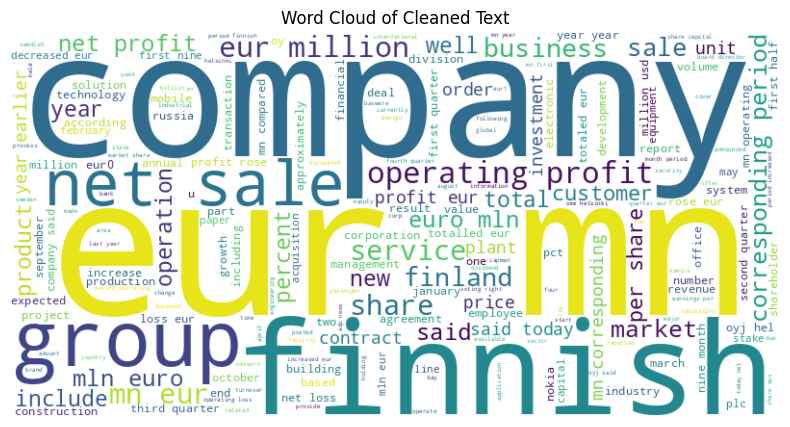

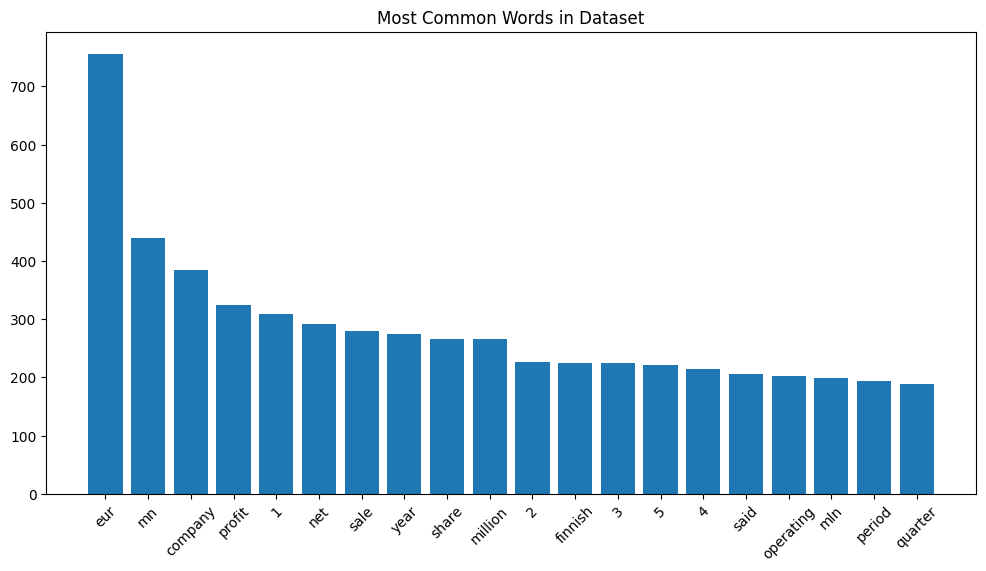

In [ ]:
# Combine all cleaned text into one string
all_words = ' '.join(data['cleaned_text'])

# Generate WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10, 5))

# display word cloud image
plt.imshow(wordcloud, interpolation='bilinear')

# remove axis for better visualization
plt.axis('off')

plt.title("Word Cloud of Cleaned Text")

plt.show()

# Word frequency analysis
word_freq = Counter(all_words.split())

# get top 20 most common words
common_words = word_freq.most_common(20)

# split words and counts
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

# Bar plot for top words
plt.figure(figsize=(12, 6))

plt.bar(words, counts)

plt.title('Most Common Words in Dataset')

plt.xticks(rotation=45)

plt.show()

### Tokenization and Padding:

In [ ]:
# input features (cleaned text) and labels
X = data['cleaned_text'].values
y = data['label'].values

# split dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# print dataset split shapes (raw text)
print("Raw X_train shape:", X_train.shape)
print("Raw X_test shape:", X_test.shape)

# initialize tokenizer with OOV token for unseen words
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# vocabulary size (+1 for padding/indexing)
vocab_size = len(tokenizer.word_index) + 1

# convert text to numerical sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# compute sequence lengths for padding strategy
lengths = [len(seq) for seq in X_train_seq]

# set max length using 95th percentile to avoid very long sequences
max_len = int(np.percentile(lengths, 95))

# apply padding to ensure uniform sequence length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# print padded shapes
print("\nX_train padded shape:", X_train_pad.shape)
print("X_test padded shape:", X_test_pad.shape)

# encode labels into integers
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# compute class weights to handle imbalance

# compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

# map correctly to class labels
class_weights = dict(zip(np.unique(y_train_enc), class_weights_array))

# convert labels to one-hot encoding for neural network
y_train_encoded = to_categorical(y_train_enc)
y_test_encoded = to_categorical(y_test_enc)

# dataset summary
print("\nVocabulary size:", vocab_size)
print("Max sequence length:", max_len)

print("\ny_train shape:", y_train_encoded.shape)
print("y_test shape:", y_test_encoded.shape)

Raw X_train shape: (1811,)
Raw X_test shape: (453,)

X_train padded shape: (1811, 28)
X_test padded shape: (453, 28)

Vocabulary size: 4863
Max sequence length: 28

y_train shape: (1811, 3)
y_test shape: (453, 3)


# Model Building and Training:

### 1. Simple RNN with a trainable Embedding layer.

In [ ]:
# build sequential model for text classification
model_rnn = Sequential()

# embedding layer: converts words into dense vectors
# input_dim = vocabulary size, output_dim = embedding size
model_rnn.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_len
))

# simple RNN layer for sequence learning
# return_sequences=False because we only need final output
model_rnn.add(SimpleRNN(
    units=64,
    return_sequences=False
))

# output layer for multi-class classification
# number of neurons = number of classes
model_rnn.add(Dense(
    units=y_train_encoded.shape[1],
    activation='softmax'
))

# compile model with loss, optimizer, and evaluation metric
model_rnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# early stopping to prevent overfitting
# stops training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# model checkpoint to save best model during training
# saves model in .h5 format (best for GUI deployment)
checkpoint = ModelCheckpoint(
    "model_rnn.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# train Simple RNN model

# start timer
start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad,              # input sequences
    y_train_encoded,          # one-hot encoded labels
    validation_split=0.2,     # validation split
    epochs=10,                # max epochs
    batch_size=32,            # batch size
    callbacks=[early_stop, checkpoint],  # early stopping + checkpoint
    class_weight=class_weights # handle class imbalance
)

# end timer
end_time = time.time()

# total training time
rnn_time = end_time - start_time

print(f"RNN Training Time: {rnn_time:.2f} seconds")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5378 - loss: 1.0294
Epoch 1: val_loss improved from None to 0.75738, saving model to model_rnn.h5



Epoch 1: finished saving model to model_rnn.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.5884 - loss: 0.9882 - val_accuracy: 0.7383 - val_loss: 0.7574
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8270 - loss: 0.6473
Epoch 2: val_loss improved from 0.75738 to 0.64409, saving model to model_rnn.h5



Epoch 2: finished saving model to model_rnn.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8280 - loss: 0.5963 - val_accuracy: 0.7328 - val_loss: 0.6441
Epoch 3/10
44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9423 - loss: 0.3029
Epoch 3: val_loss did not improve from 0.64409
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9427 - loss: 0.2636 - val_accuracy: 0.7410 - val_loss: 0.6944
Epoch 4/10
44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9803 - loss: 0.1102
Epoch 4: val_loss did not improve from 0.64409
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9779 - loss: 0.1093 - val_accuracy: 0.7603 - val_loss: 0.7101
Epoch 5/10
43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9906 - loss: 0.0477
Epoch 5: val_loss did not improve from 0.64409
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9896 - loss: 0.0538 - val_accuracy: 0.7410 - val_loss: 0.7834
Epoch 6/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9910 - loss: 0.0459
Epoch 6

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7152 - loss: 0.7034
Simple RNN Test Accuracy: 0.7152317762374878
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.46      0.39        56
           1       0.88      0.86      0.87       276
           2       0.58      0.50      0.54       121

    accuracy                           0.72       453
   macro avg       0.60      0.61      0.60       453
weighted avg       0.73      0.72      0.72       453



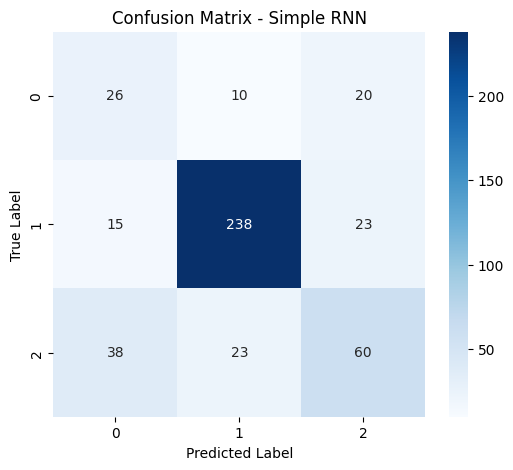

In [ ]:
# evaluate model performance on test data
loss, acc = model_rnn.evaluate(X_test_pad, y_test_encoded)

print("Simple RNN Test Accuracy:", acc)

# predict probabilities for test data
y_pred = model_rnn.predict(X_test_pad)

# convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# convert true one-hot labels to class labels
y_true = np.argmax(y_test_encoded, axis=1)

# classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Simple RNN")

plt.show()

### 2. LSTM with a trainable Embedding layer.

In [ ]:
# build sequential LSTM model for text classification
model_lstm = Sequential()

# embedding layer: converts words into dense vector representations
model_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_len
))

# LSTM layer for capturing sequential dependencies in text
model_lstm.add(LSTM(
    units=64
    # return_sequences=False by default (we only need final output)
))

# output layer for multi-class classification
model_lstm.add(Dense(
    units=y_train_encoded.shape[1],
    activation='softmax'
))

# compile model with loss function, optimizer, and accuracy metric
model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# save best LSTM model in .h5 format
checkpoint = ModelCheckpoint(
    "model_lstm.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# train LSTM model

start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad,              # input sequences
    y_train_encoded,          # labels (one-hot encoded)
    validation_split=0.2,     # validation split
    epochs=10,                # max epochs
    batch_size=32,            # batch size
    callbacks=[early_stop, checkpoint],  # early stopping + best model saving
    class_weight=class_weights # handle class imbalance
)

end_time = time.time()
lstm_time = end_time - start_time

print(f"LSTM Training Time: {lstm_time:.2f} seconds")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5530 - loss: 1.0826
Epoch 1: val_loss improved from None to 0.69137, saving model to model_lstm.h5



Epoch 1: finished saving model to model_lstm.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6188 - loss: 1.0162 - val_accuracy: 0.7355 - val_loss: 0.6914
Epoch 2/10
44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7483 - loss: 0.6913
Epoch 2: val_loss improved from 0.69137 to 0.63773, saving model to model_lstm.h5



Epoch 2: finished saving model to model_lstm.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7562 - loss: 0.6791 - val_accuracy: 0.6749 - val_loss: 0.6377
Epoch 3/10
44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7591 - loss: 0.5511
Epoch 3: val_loss did not improve from 0.63773
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7797 - loss: 0.5466 - val_accuracy: 0.6419 - val_loss: 0.8029
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7492 - loss: 0.5471
Epoch 4: val_loss improved from 0.63773 to 0.59617, saving model to model_lstm.h5



Epoch 4: finished saving model to model_lstm.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7859 - loss: 0.5351 - val_accuracy: 0.7300 - val_loss: 0.5962
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7834 - loss: 0.4935
Epoch 5: val_loss did not improve from 0.59617
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7735 - loss: 0.5091 - val_accuracy: 0.7273 - val_loss: 0.6661
Epoch 6/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8554 - loss: 0.4868
Epoch 6: val_loss did not improve from 0.59617
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8343 - loss: 0.4801 - val_accuracy: 0.7052 - val_loss: 0.6640
Epoch 7/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8387 - loss: 0.4534
Epoch 7: val_loss did not improve from 0.59617
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8391 - loss: 0.4642 - val_accuracy: 0.7576 - val_loss: 0.6194
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8917 - loss: 0.3973
Epoch 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7770 - loss: 0.6200
LSTM Test Accuracy: 0.7770419716835022
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.90      0.92      0.91       276
           2       0.58      0.81      0.68       121

    accuracy                           0.78       453
   macro avg       0.49      0.58      0.53       453
weighted avg       0.70      0.78      0.73       453



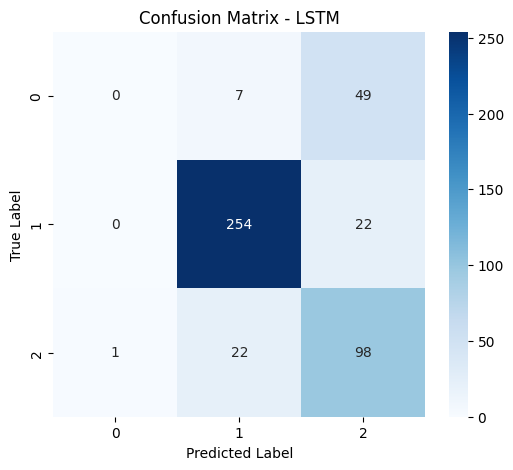

In [ ]:
# evaluate model on test data
loss, acc = model_lstm.evaluate(X_test_pad, y_test_encoded)

print("LSTM Test Accuracy:", acc)

# predict probabilities for test set
y_pred_lstm = model_lstm.predict(X_test_pad)

# convert probabilities → class labels
y_pred_classes_lstm = np.argmax(y_pred_lstm, axis=1)

# convert true labels → class labels
y_true = np.argmax(y_test_encoded, axis=1)

# classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_classes_lstm,
    zero_division=0  # avoids warning for missing class predictions
))

# confusion matrix
cm = confusion_matrix(y_true, y_pred_classes_lstm)

# visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### 3. LSTM with pretrained Word2Vec embeddings.

In [ ]:
# load pretrained Google News Word2Vec model (300 dimensions)
word2vec = api.load("word2vec-google-news-300")

embedding_dim = 300

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
# initialize embedding matrix with zeros
# this creates a fixed-size matrix where each row represents a word in the vocabulary
# words not found in pretrained Word2Vec will remain as zero vectors (no semantic meaning)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# map each word in tokenizer vocabulary to Word2Vec vector
for word, i in tokenizer.word_index.items():
    if word in word2vec:
        embedding_matrix[i] = word2vec[word]


# LSTM model with pretrained Word2Vec embeddings
model_w2v_lstm = Sequential()

# embedding layer (pretrained, frozen)
model_w2v_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    #input_length=max_len,
    trainable=False  # IMPORTANT: freeze embeddings
))

# LSTM layer
model_w2v_lstm.add(LSTM(64))

# output layer
model_w2v_lstm.add(Dense(
    units=y_train_encoded.shape[1],
    activation='softmax'
))

# compile model
model_w2v_lstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# save best  model in .h5 format
checkpoint = ModelCheckpoint(
    "model_w2v_lstm.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

start_time = time.time()
history_w2v = model_w2v_lstm.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)
end_time = time.time()
w2v_time = end_time - start_time

print(f"Word2Vec LSTM Training Time: {w2v_time:.2f} seconds")

Epoch 1/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7179 - loss: 0.7704
Epoch 1: val_loss improved from None to 0.53633, saving model to model_w2v_lstm.h5



Epoch 1: finished saving model to model_w2v_lstm.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.7017 - loss: 0.7503 - val_accuracy: 0.7355 - val_loss: 0.5363
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7391 - loss: 0.6487
Epoch 2: val_loss improved from 0.53633 to 0.47819, saving model to model_w2v_lstm.h5



Epoch 2: finished saving model to model_w2v_lstm.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7390 - loss: 0.6487 - val_accuracy: 0.7548 - val_loss: 0.4782
Epoch 3/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7704 - loss: 0.5887
Epoch 3: val_loss did not improve from 0.47819
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7776 - loss: 0.5934 - val_accuracy: 0.7273 - val_loss: 0.5177
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7708 - loss: 0.5359
Epoch 4: val_loss did not improve from 0.47819
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7728 - loss: 0.5646 - val_accuracy: 0.7163 - val_loss: 0.5824
Epoch 5/10
44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7730 - loss: 0.5511
Epoch 5: val_loss did not improve from 0.47819
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7887 - loss: 0.5474 - val_accuracy: 0.7493 - val_loss: 0.5016
Epoch 6/10
44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7811 - loss: 0.5400
Ep


Epoch 7: finished saving model to model_w2v_lstm.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8260 - loss: 0.4879 - val_accuracy: 0.8044 - val_loss: 0.4606
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8587 - loss: 0.4249
Epoch 8: val_loss did not improve from 0.46056
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8791 - loss: 0.3925 - val_accuracy: 0.8292 - val_loss: 0.4990
Epoch 9/10
44/46 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8923 - loss: 0.3538
Epoch 9: val_loss did not improve from 0.46056
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8854 - loss: 0.3626 - val_accuracy: 0.8512 - val_loss: 0.4922
Epoch 10/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9442 - loss: 0.2654
Epoch 10: val_loss improved from 0.46056 to 0.42488, saving model to model_w2v_lstm.h5



Epoch 10: finished saving model to model_w2v_lstm.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9282 - loss: 0.2956 - val_accuracy: 0.8623 - val_loss: 0.4249
Word2Vec LSTM Training Time: 25.88 seconds


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8698 - loss: 0.3975
Word2Vec LSTM Test Accuracy: 0.8697571754455566
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68        56
           1       0.96      0.93      0.95       276
           2       0.77      0.81      0.79       121

    accuracy                           0.87       453
   macro avg       0.80      0.81      0.81       453
weighted avg       0.87      0.87      0.87       453



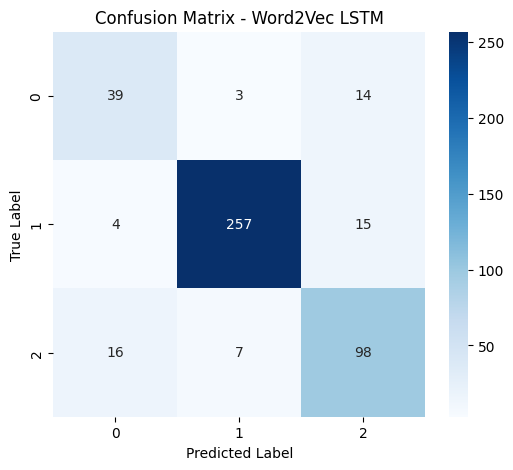

In [ ]:
# evaluate model on test data
loss, acc = model_w2v_lstm.evaluate(X_test_pad, y_test_encoded)

print("Word2Vec LSTM Test Accuracy:", acc)

# predict probabilities on test set
y_pred_w2v = model_w2v_lstm.predict(X_test_pad)

# convert probabilities to class labels
y_pred_classes_w2v = np.argmax(y_pred_w2v, axis=1)

# convert true labels to class labels
y_true = np.argmax(y_test_encoded, axis=1)

# classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_classes_w2v,
    zero_division=0
))

# confusion matrix
cm = confusion_matrix(y_true, y_pred_classes_w2v)

# visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Word2Vec LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Visualization:

Compared the performance of the Model 1 vs. Model 2 vs. Model 3.

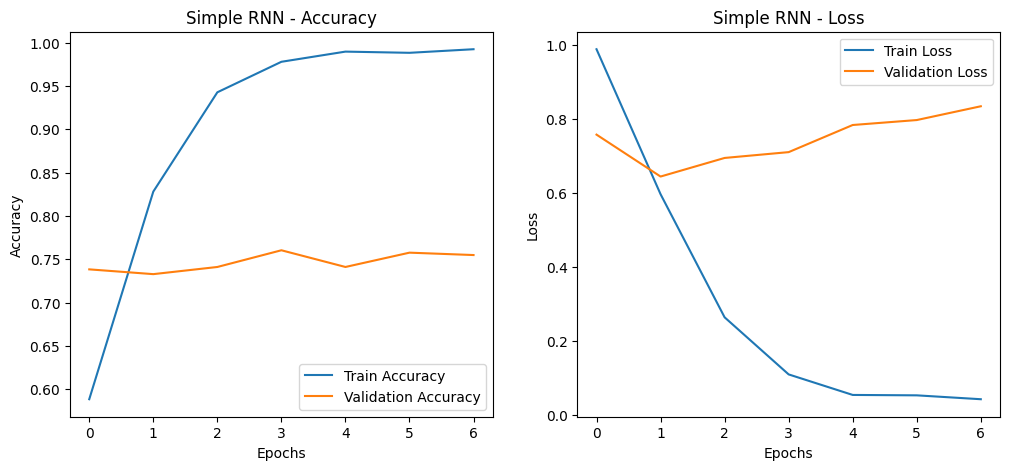

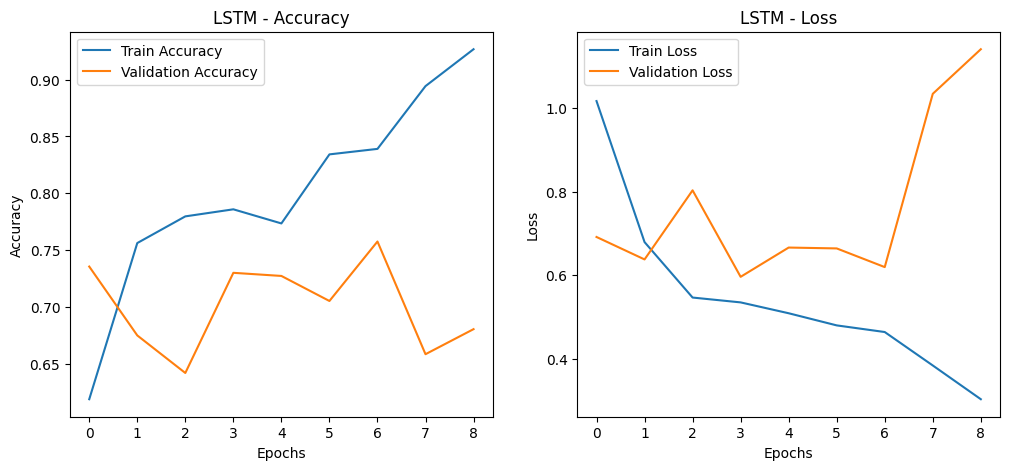

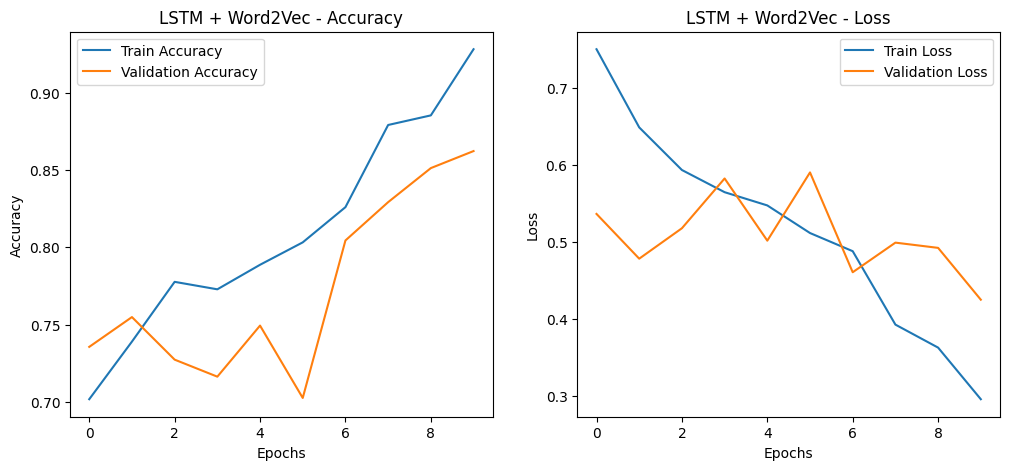

In [ ]:

# function to plot training history for each model
def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# plot for all three models
plot_history(history_rnn, "Simple RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_w2v, "LSTM + Word2Vec")

LSTM and Word2Vec models show smoother convergence compared to Simple RNN, indicating better learning of long-term dependencies.

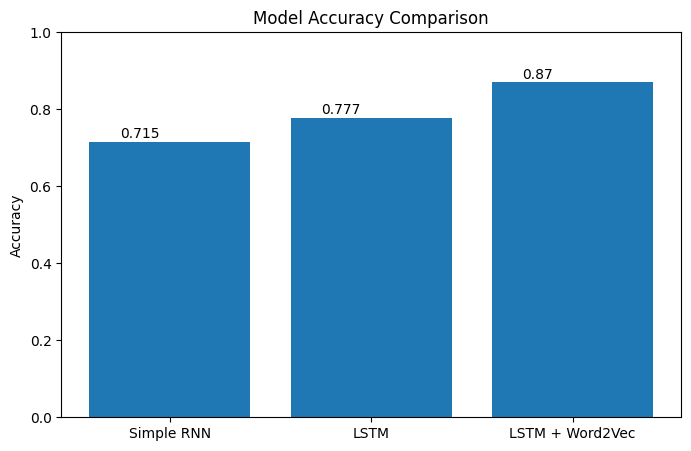

In [ ]:
# store model names
models = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']

# store test accuracies from each model
accuracies = [
    model_rnn.evaluate(X_test_pad, y_test_encoded, verbose=0)[1],
    model_lstm.evaluate(X_test_pad, y_test_encoded, verbose=0)[1],
    model_w2v_lstm.evaluate(X_test_pad, y_test_encoded, verbose=0)[1]
]

# plot bar chart
plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

# add accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.15, yval + 0.01, round(yval, 3))

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

# Error Analysis:

### Incorrect predictions.

In [ ]:
# predict classes from model
y_pred = model_lstm.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

# true labels
y_true = np.argmax(y_test_encoded, axis=1)

# reverse label encoding for readability
labels = label_encoder.inverse_transform(y_true)
pred_labels = label_encoder.inverse_transform(y_pred_classes)

# convert test text back for inspection
X_test_text = X_test  # original text split before tokenization

# find misclassified samples
errors = []

for i in range(len(y_true)):
    if y_true[i] != y_pred_classes[i]:
        errors.append({
            "Text": X_test_text[i],
            "Actual": labels[i],
            "Predicted": pred_labels[i]
        })

# show first 3 misclassified examples
print("Misclassified Examples:\n")

for i, err in enumerate(errors[:3]):
    print(f"Example {i+1}")
    print("Text:", err["Text"])
    print("Actual:", err["Actual"])
    print("Predicted:", err["Predicted"])
    print("-" * 80)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Misclassified Examples:

Example 1
Text: kemira share closed x20ac 16 66 22us 71
Actual: neutral
Predicted: positive
--------------------------------------------------------------------------------
Example 2
Text: company slipped operating loss eur 2 6 million profit eur 1 3 million
Actual: negative
Predicted: positive
--------------------------------------------------------------------------------
Example 3
Text: 2009 comptel slipped net loss eur2 1 profit eur6 6 previous year
Actual: negative
Predicted: positive
--------------------------------------------------------------------------------


From these examples, we observe:

1. Numerical bias
  
    Model misinterprets financial numbers as sentiment indicators

2. Weak sentiment signal detection

    Subtle positive words like “improved” are sometimes ignored

3. Financial text complexity

    Sentences are fact-heavy, not emotion-heavy -> harder for NLP models

LSTM was selected for error analysis because it provides a balanced performance between Simple RNN and Word2Vec-based LSTM. Unlike Simple RNN, it captures long-term dependencies effectively, while unlike Word2Vec LSTM, it does not rely on external pretrained embeddings, making its errors more representative of model learning behavior.


Misclassified examples indicate that the model struggles with financial domain-specific language. In some cases, numerical values are incorrectly interpreted as sentiment indicators, leading to false positive or negative predictions. Additionally, subtle sentiment expressions such as ‘improved’ are sometimes not strongly weighted, resulting in neutral predictions. These errors highlight the challenges of analyzing fact-heavy financial text, where sentiment is implicit rather than explicitly expressed.

### Evaluate Model Complexity vs. Performance.

**Interpretation**

Simple RNN

* Lowest complexity
* Struggles with long-term dependencies
* Lowest performance

LSTM

* Medium complexity
* Better memory control (gates)
* Slight improvement over RNN

Word2Vec + LSTM
* Highest complexity
* Uses pretrained semantic knowledge
* Significant performance boost (0.81)

# GUI for Real Time Prediction:

In [ ]:
# load best model
model = load_model("model_w2v_lstm.h5")

In [ ]:
def predict_sentiment(text):

    # preprocess input
    cleaned = text_cleaning(text)

    # convert to sequence
    seq = tokenizer.texts_to_sequences([cleaned])

    # padding
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    # prediction
    pred = model.predict(padded)
    class_idx = np.argmax(pred)

    # convert label back
    label = label_encoder.inverse_transform([class_idx])[0]

    return label

In [ ]:
import gradio as gr

# create Gradio interface for real-time prediction
interface = gr.Interface(

    fn=predict_sentiment,  # function that takes input text and returns prediction

    # input textbox for user to enter financial text
    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter financial text for sentiment analysis...",
        label="Input Text"
    ),

    # output textbox to display predicted sentiment
    outputs=gr.Textbox(
        label="Predicted Sentiment"
    ),

    # title of the application
    title="Financial Sentiment Analysis System",

    # centered description using HTML for better UI formatting
    description="""
<div style="text-align: center;">
    <p><b>Financial Text Classification Model</b></p>
    <p>Classifies input text into: Positive | Neutral | Negative</p>
    <p>Model: LSTM with pretrained Word2Vec embeddings</p>
</div>
""",

    # soft theme for clean and modern appearance
    theme=gr.themes.Soft(),

    # example inputs for quick testing
    examples=[
        ["The company reported a strong increase in quarterly profits and exceeded expectations."],
        ["The firm faced a decline in revenue due to rising operational costs."],
        ["The company held its annual meeting to discuss financial performance."]
    ],

    # disable flagging
    flagging_mode="never"
)

# launch the interface (share=True generates public link in Colab)
interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://36b9307c8ad55539bf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://36b9307c8ad55539bf.gradio.live
